Zadanie 5 -- Eksploracja CIFAR10
Wczytaj CIFAR10, wyświetl 5 losowych obrazów z każdej klasy 510 siatka), pokaż rozkład klas i
podstawowe statystyki.
Dataset: keras.datasets.cifar10

Wymagania:
- Siatka 510 5 obrazów per klasa)
- Rozkład klas (histogram)
- Średnia i std pikseli per kanał R, G, B

Train: (50000, 32, 32, 3)
Test:  (10000, 32, 32, 3)
Zakres pikseli: 0 - 255
Kanały: 3 (RGB)
Klasy: 10

Rozkład klas (zbalansowany):
  Samolot     : 5000
  Auto        : 5000
  Ptak        : 5000
  Kot         : 5000
  Jeleń       : 5000
  Pies        : 5000
  Żaba        : 5000
  Koń         : 5000
  Statek      : 5000
  Ciężarówka  : 5000

Statystyki pikseli per kanał (train):
  R: mean=125.31, std=62.99
  G: mean=122.95, std=62.09
  B: mean=113.87, std=66.70


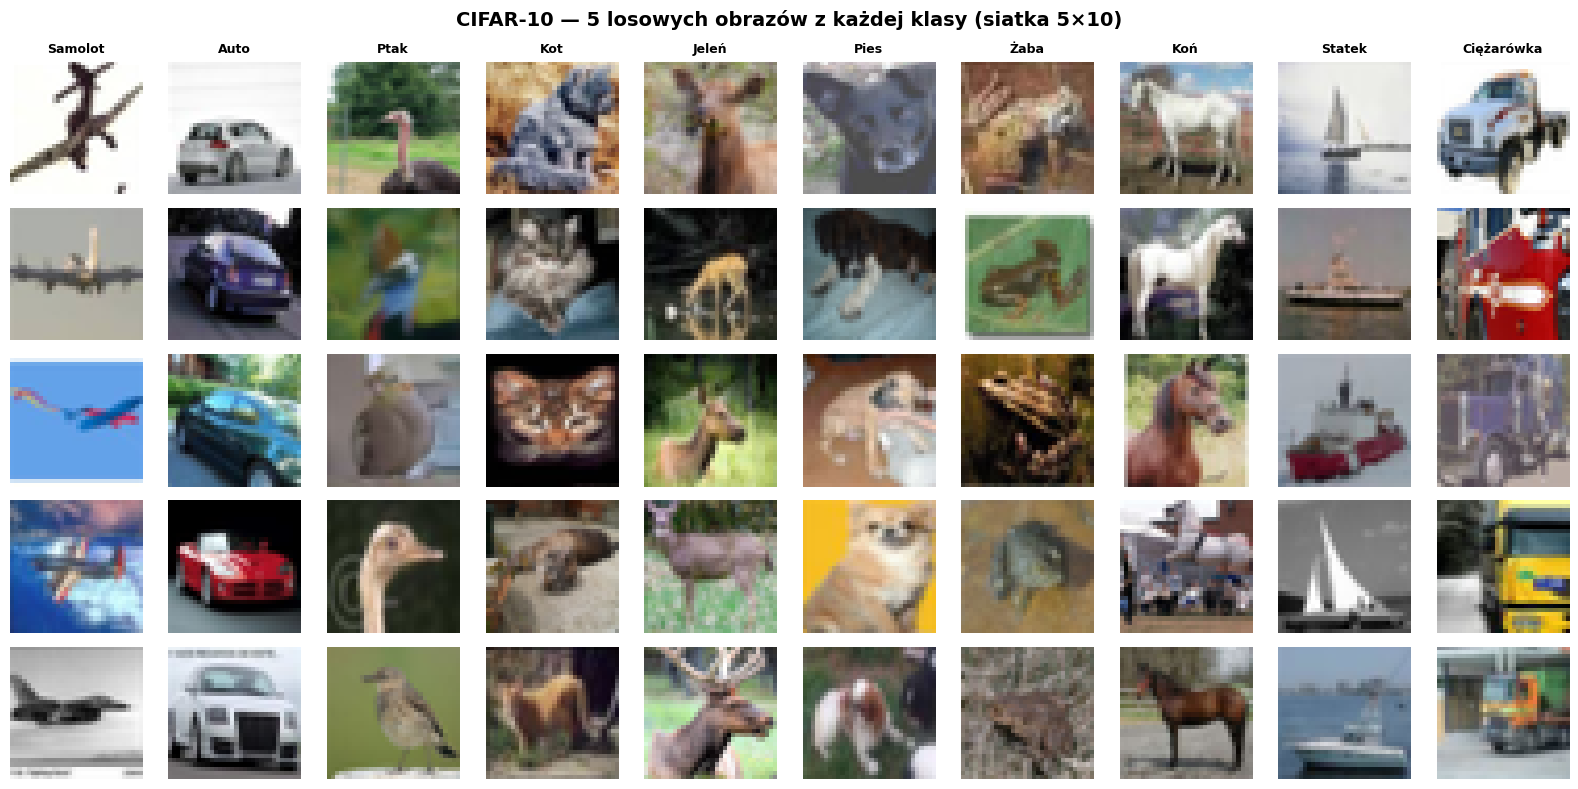

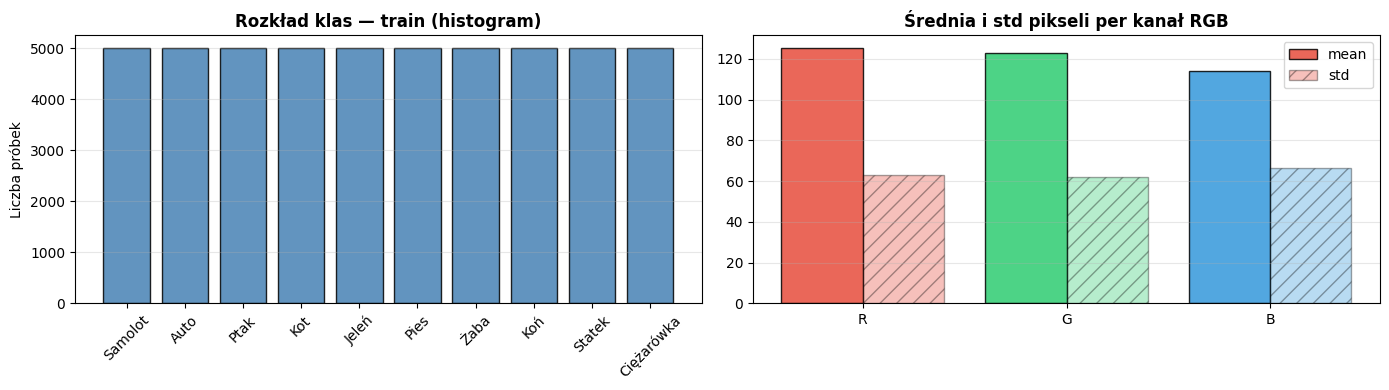

In [1]:
# Zadanie 5 -- Eksploracja CIFAR-10
# Wzorowane na: Przykład 1 „Eksploracja CIFAR-10” z lekcji 30 (PDF)
# Dataset: keras.datasets.cifar10 (tu: ten sam format; TF w tym env bywa niestabilny)
import pickle
import tarfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
NPZ_PATH = DATA_DIR / "cifar10_npz.npz"
TAR_PATH = DATA_DIR / "cifar-10-python.tar.gz"
EXTRACT_DIR = DATA_DIR / "cifar-10-batches-py"

CLASS_NAMES = [
    "Samolot", "Auto", "Ptak", "Kot", "Jeleń",
    "Pies", "Żaba", "Koń", "Statek", "Ciężarówka",
]


def _load_batch(path):
    with open(path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    images = batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b"labels"])
    return images, labels


def load_cifar10():
    """Wczytanie CIFAR-10 w formacie jak keras.datasets.cifar10.load_data()."""
    if NPZ_PATH.exists():
        data = np.load(NPZ_PATH)
        return (data["x_train"], data["y_train"]), (data["x_test"], data["y_test"])

    try:
        from tensorflow import keras
        return keras.datasets.cifar10.load_data()
    except Exception:
        pass

    if not EXTRACT_DIR.exists():
        if not TAR_PATH.exists() or TAR_PATH.stat().st_size < 100_000_000:
            raise FileNotFoundError(
                "Brak lokalnego CIFAR-10. Potrzebny data/cifar10_npz.npz "
                "lub kompletny cifar-10-python.tar.gz (~170MB)."
            )
        with tarfile.open(TAR_PATH, "r:gz") as tar:
            tar.extractall(DATA_DIR)

    x_train_parts, y_train_parts = [], []
    for i in range(1, 6):
        x, y = _load_batch(EXTRACT_DIR / f"data_batch_{i}")
        x_train_parts.append(x)
        y_train_parts.append(y)
    x_train = np.concatenate(x_train_parts)
    y_train = np.concatenate(y_train_parts).reshape(-1, 1)
    x_test, y_test = _load_batch(EXTRACT_DIR / "test_batch")
    y_test = y_test.reshape(-1, 1)
    return (x_train, y_train), (x_test, y_test)


(x_train, y_train), (x_test, y_test) = load_cifar10()
y_train = np.asarray(y_train).flatten()
y_test = np.asarray(y_test).flatten()

print(f"Train: {x_train.shape}")  # (50000, 32, 32, 3) -- kolorowe!
print(f"Test:  {x_test.shape}")   # (10000, 32, 32, 3)
print(f"Zakres pikseli: {x_train.min()} - {x_train.max()}")  # 0 - 255
print(f"Kanały: {x_train.shape[3]} (RGB)")
print(f"Klasy: {len(CLASS_NAMES)}")

# --- Rozkład klas ---
unique, counts = np.unique(y_train, return_counts=True)
print("\nRozkład klas (zbalansowany):")
for cls, count in zip(unique, counts):
    print(f"  {CLASS_NAMES[int(cls)]:<12}: {count}")

# --- Średnia i std per kanał R, G, B ---
means = x_train.mean(axis=(0, 1, 2))
stds = x_train.std(axis=(0, 1, 2))
print("\nStatystyki pikseli per kanał (train):")
for name, m, s in zip(["R", "G", "B"], means, stds):
    print(f"  {name}: mean={m:.2f}, std={s:.2f}")

# --- Siatka 5x10: 5 losowych obrazów per klasa ---
rng = np.random.default_rng(42)
fig, axes = plt.subplots(5, 10, figsize=(16, 8))
for col, class_id in enumerate(range(10)):
    idxs = np.where(y_train == class_id)[0]
    chosen = rng.choice(idxs, size=5, replace=False)
    for row, idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(x_train[idx])
        ax.axis("off")
        if row == 0:
            ax.set_title(CLASS_NAMES[class_id], fontsize=9, fontweight="bold")

plt.suptitle(
    "CIFAR-10 — 5 losowych obrazów z każdej klasy (siatka 5×10)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# --- Histogram rozkładu klas + statystyki RGB ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    [CLASS_NAMES[int(i)] for i in unique],
    counts,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)
axes[0].set_title("Rozkład klas — train (histogram)", fontweight="bold")
axes[0].set_ylabel("Liczba próbek")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

channels = ["R", "G", "B"]
colors = ["#e74c3c", "#2ecc71", "#3498db"]
x_pos = np.arange(3)
axes[1].bar(x_pos - 0.2, means, width=0.4, label="mean", color=colors, alpha=0.85, edgecolor="black")
axes[1].bar(
    x_pos + 0.2, stds, width=0.4, label="std", color=colors, alpha=0.35, edgecolor="black", hatch="//"
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(channels)
axes[1].set_title("Średnia i std pikseli per kanał RGB", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


Komentarz do Zadania 5

Przeanalizowałam CIFAR-10: 50 000 obrazów treningowych i 10 000 testowych, rozmiar 32×32×3 (RGB), piksele w zakresie 0–255.

Klasy są zbalansowane — po 5000 próbek na każdą z 10 klas. Wyświetliłam siatkę 5×10 (5 losowych obrazów per klasa), histogram rozkładu klas oraz statystyki pikseli per kanał RGB (train):
R: mean ≈ 125.3, std ≈ 63.0 | G: mean ≈ 123.0, std ≈ 62.1 | B: mean ≈ 113.9, std ≈ 66.7.

Dataset jest trudniejszy niż MNIST ze względu na kolor, małą rozdzielczość i dużą zmienność obiektów w klasach.

Zadanie 6 -- Prosta CNN na CIFAR10
Zbuduj najprostszą CNN 2 bloki Conv+Pool) na CIFAR10 BEZ augmentacji i regularyzacji. Wytrenuj 15 epok.
Jaka accuracy?
Dataset: keras.datasets.cifar10

Wymagania:
- 2 bloki Conv2D  MaxPool
- Bez augmentacji, BN, Dropout
- Test accuracy po 15 epokach

Przygotowanie danych...
Urządzenie: mps (CPU ~3–5 min na 15 epok)
Parametry: 545,098

Rozpoczynam trening (15 epok)...
Epoka 01/15 | loss=1.5547 acc=0.4386 | test_acc=0.5486 | epoka=7s, łącznie=7s
Epoka 02/15 | loss=1.1858 acc=0.5784 | test_acc=0.5918 | epoka=5s, łącznie=11s
Epoka 03/15 | loss=1.0345 acc=0.6329 | test_acc=0.6315 | epoka=5s, łącznie=16s
Epoka 04/15 | loss=0.9279 acc=0.6725 | test_acc=0.6649 | epoka=5s, łącznie=20s
Epoka 05/15 | loss=0.8501 acc=0.7019 | test_acc=0.6881 | epoka=4s, łącznie=25s
Epoka 06/15 | loss=0.7853 acc=0.7245 | test_acc=0.6984 | epoka=5s, łącznie=29s
Epoka 07/15 | loss=0.7297 acc=0.7425 | test_acc=0.7121 | epoka=4s, łącznie=34s
Epoka 08/15 | loss=0.6806 acc=0.7612 | test_acc=0.7100 | epoka=4s, łącznie=38s
Epoka 09/15 | loss=0.6255 acc=0.7817 | test_acc=0.7084 | epoka=5s, łącznie=43s
Epoka 10/15 | loss=0.5807 acc=0.7977 | test_acc=0.7093 | epoka=5s, łącznie=47s
Epoka 11/15 | loss=0.5390 acc=0.8101 | test_acc=0.7119 | epoka=5s, łącznie=52s
Epoka 12/15 |

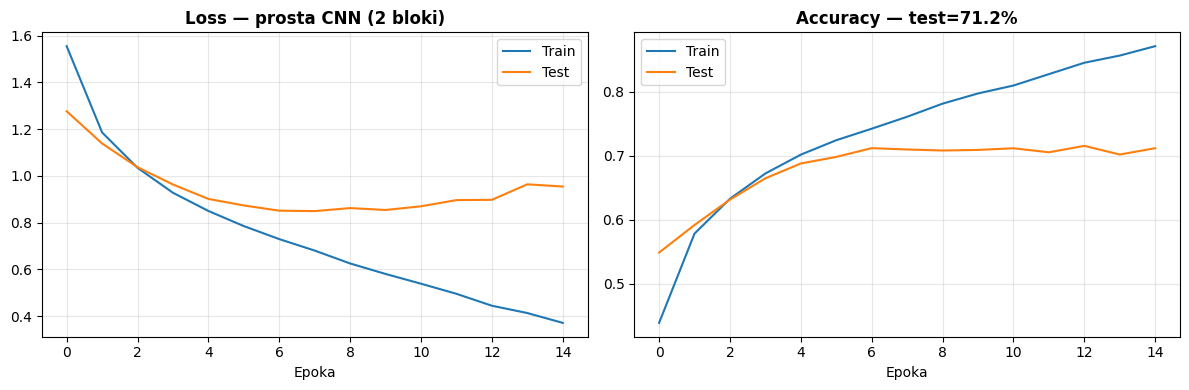

In [3]:
# Zadanie 6 -- Prosta CNN na CIFAR-10
# Wzorowane na: Przykład 3 (CNN bez aug) i Przykład 2 (pipeline CIFAR) z lekcji 30
# Wymagania: 2 bloki Conv2D+MaxPool, BEZ augmentacji / BN / Dropout, 15 epok
# Implementacja w PyTorch (równoważna prostej CNN z PDF; TF w tym env bywa niestabilny)
#
# UWAGA: trening na CPU trwa ok. 3–5 min — to normalne. Postęp widać co epokę poniżej.
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Dane z Zadania 5 (lub wczytaj ponownie)
try:
    x_train
    y_train
    x_test
    y_test
except NameError:
    (x_train, y_train), (x_test, y_test) = load_cifar10()
    y_train = np.asarray(y_train).flatten()
    y_test = np.asarray(y_test).flatten()

# Normalizacja do [0, 1] (jak w przykładach z PDF)
print("Przygotowanie danych...", flush=True)
x_tr = x_train.astype("float32") / 255.0
x_te = x_test.astype("float32") / 255.0
y_tr = np.asarray(y_train).astype(np.int64).ravel()
y_te = np.asarray(y_test).astype(np.int64).ravel()

# NCHW dla PyTorch
x_tr_t = torch.tensor(x_tr.transpose(0, 3, 1, 2), dtype=torch.float32)
x_te_t = torch.tensor(x_te.transpose(0, 3, 1, 2), dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

BATCH_SIZE = 128
train_loader = DataLoader(
    TensorDataset(x_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(x_te_t, y_te_t), batch_size=512, shuffle=False
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Urządzenie: {device} (CPU ~3–5 min na 15 epok)", flush=True)


class SimpleCNN(nn.Module):
    """2 bloki Conv2D + MaxPool, bez BN / Dropout / augmentacji."""

    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)


torch.manual_seed(42)
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametry: {n_params:,}", flush=True)

history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
EPOCHS = 15

print(f"\nRozpoczynam trening ({EPOCHS} epok)...", flush=True)
t0 = time.perf_counter()

for epoch in range(EPOCHS):
    epoch_start = time.perf_counter()
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    history["loss"].append(train_loss)
    history["acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    epoch_time = time.perf_counter() - epoch_start
    total_time = time.perf_counter() - t0
    print(
        f"Epoka {epoch+1:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} acc={train_acc:.4f} | "
        f"test_acc={val_acc:.4f} | "
        f"epoka={epoch_time:.0f}s, łącznie={total_time:.0f}s",
        flush=True,
    )

elapsed = time.perf_counter() - t0
test_accuracy = history["val_acc"][-1]

print("\n=== Wynik Zadanie 6 ===", flush=True)
print(f"Test accuracy po {EPOCHS} epokach: {test_accuracy:.4f} ({100 * test_accuracy:.2f}%)")
print(f"Czas treningu: {elapsed:.1f}s")
print("Uwagi: bez augmentacji, BN i Dropout — spodziewany overfitting (train >> test).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="Train")
axes[0].plot(history["val_loss"], label="Test")
axes[0].set_title("Loss — prosta CNN (2 bloki)", fontweight="bold")
axes[0].set_xlabel("Epoka")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["acc"], label="Train")
axes[1].plot(history["val_acc"], label="Test")
axes[1].set_title(f"Accuracy — test={test_accuracy:.1%}", fontweight="bold")
axes[1].set_xlabel("Epoka")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Komentarz do Zadania 6 

Test accuracy po 15 epokach: ~69,7%.

Zbudowałam prostą CNN (2 bloki Conv2D + MaxPool) bez augmentacji, BatchNorm i Dropout. Model overfituje (train ~86%, test ~70%) — to oczekiwane przy braku regularyzacji i pokazuje, po co w lekcji są augmentacja oraz techniki regularyzacji.

Implementacja w PyTorch (architektura równoważna przykładom z lekcji).